# Notebook 01 - Tạo workload từ Azure Packing Trace (.sqlite)

Notebook này biến file `.sqlite` của Azure Packing Trace thành các file dữ liệu dùng cho project DRL Energy Resource Management.

## File đầu ra

Notebook này tạo 4 file trong thư mục `data/`:

1. `workload_real_original.csv`

   Azure original workload (workload gốc từ Azure), chưa rescale.

2. `workload_real_multiphase.csv`

   Azure-derived multiphase workload (workload nhiều pha dẫn xuất từ Azure), có đủ low / medium / high demand để train PPO cho bài toán Dynamic Power Management.

3. `workload_real.csv`

   File alias giống `workload_real_multiphase.csv`, giúp Notebook 2 dễ load nếu đang dùng tên cũ.

4. `vm_snapshots.csv`

   VM snapshot (ảnh chụp trạng thái VM theo timestep), dùng để mô phỏng VM placement và migration.

## Vì sao cần 2 workload?

- Workload gốc từ Azure giúp chứng minh project có dùng dữ liệu thực tế.
- Workload nhiều pha giúp PPO học được hành vi quản lý nguồn động:
  - low demand (tải thấp): giảm DVFS, sleep/off host;
  - medium demand (tải trung bình): cân bằng năng lượng và SLA;
  - high demand (tải cao): wake/boot host để tránh SLA violation.

In [1]:

# Nếu bạn chạy notebook lần đầu mà báo thiếu thư viện, bỏ comment dòng dưới rồi chạy 1 lần:
# !pip install pandas numpy matplotlib


In [2]:

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.azure_workload_utils import extract_workload_from_azure_packing, extract_vm_snapshots_from_azure_packing

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project



## Bước 1 - Khai báo đường dẫn file SQLite

Bạn chỉ cần sửa `DB_PATH` cho đúng máy của bạn.

Ví dụ:
- Windows: `r"D:\HK6\...\packing_trace_zone_a_v1.sqlite"`
- Hoặc nếu bạn chép file vào thư mục `data`, có thể dùng đường dẫn tương đối.


In [3]:
DB_PATH = PROJECT_ROOT / "data" / "packing_trace_zone_a_v1.sqlite"

# File workload gốc từ Azure trace, chưa rescale.
ORIGINAL_WORKLOAD_CSV = PROJECT_ROOT / "data" / "workload_real_original.csv"

# File workload nhiều pha low / medium / high dùng để train PPO chính.
MULTIPHASE_WORKLOAD_CSV = PROJECT_ROOT / "data" / "workload_real_multiphase.csv"

# File alias để Notebook 2 cũ vẫn đọc được nếu đang dùng data/workload_real.csv.
# Mình sẽ lưu file này giống MULTIPHASE_WORKLOAD_CSV.
OUTPUT_CSV = PROJECT_ROOT / "data" / "workload_real.csv"

# File VM snapshot dùng cho mô phỏng VM placement / migration.
VM_SNAPSHOT_CSV = PROJECT_ROOT / "data" / "vm_snapshots.csv"

print("DB_PATH =", DB_PATH)
print("ORIGINAL_WORKLOAD_CSV =", ORIGINAL_WORKLOAD_CSV)
print("MULTIPHASE_WORKLOAD_CSV =", MULTIPHASE_WORKLOAD_CSV)
print("OUTPUT_CSV alias =", OUTPUT_CSV)
print("VM_SNAPSHOT_CSV =", VM_SNAPSHOT_CSV)

DB_PATH = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\packing_trace_zone_a_v1.sqlite
ORIGINAL_WORKLOAD_CSV = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_original.csv
MULTIPHASE_WORKLOAD_CSV = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_multiphase.csv
OUTPUT_CSV alias = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real.csv
VM_SNAPSHOT_CSV = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_pro

workload_real_original.csv   → để báo cáo dữ liệu gốc.

workload_real_multiphase.csv → để train PPO có đủ tải thấp/trung bình/cao.

workload_real.csv            → alias, giúp Notebook 2 không bị lỗi nếu đang load tên cũ.


## Bước 2 - Kiểm tra file có tồn tại không
Nếu cell này in ra `True` là ổn.


In [4]:

Path(DB_PATH).exists()


True


## Bước 3 - Xem nhanh trong database có những bảng nào

Bước này để bạn hiểu dữ liệu trước khi trích workload.


In [5]:

conn = sqlite3.connect(DB_PATH)

tables_df = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn
)
tables_df


,name
0,vm
1,vmType



## Bước 4 - Xem schema và số dòng của 2 bảng chính
Ở file bạn upload, thường sẽ có:

- `vm`
- `vmType`


In [6]:

for table_name in ["vm", "vmType"]:
    print("\n" + "=" * 70)
    print("TABLE:", table_name)
    schema = pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)
    print(schema)
    count_df = pd.read_sql_query(f"SELECT COUNT(*) AS row_count FROM {table_name};", conn)
    print("Số dòng =", int(count_df.loc[0, "row_count"]))



TABLE: vm
   cid       name     type  notnull dflt_value  pk
0    0       vmId  INTEGER        1       None   1
1    1   tenantId  INTEGER        0       None   0
2    2   vmTypeId  INTEGER        0       None   0
3    3   priority  INTEGER        0       None   0
4    4  starttime     REAL        0       None   0
5    5    endtime     REAL        0       None   0
Số dòng = 5559800

TABLE: vmType
   cid       name     type  notnull dflt_value  pk
0    0         id  INTEGER        0       None   1
1    1   vmTypeId  INTEGER        0       None   0
2    2  machineId  INTEGER        0       None   0
3    3       core   DOUBLE        0       None   0
4    4     memory   DOUBLE        0       None   0
5    5        hdd   DOUBLE        0       None   0
6    6        ssd   DOUBLE        0       None   0
7    7        nic   DOUBLE        0       None   0
Số dòng = 4619



## Bước 5 - Xem vài dòng đầu để hiểu dữ liệu

Bạn sẽ thấy:
- `vm.starttime`, `vm.endtime`
- `vm.vmTypeId`
- `vmType.core`

Đó là các cột quan trọng nhất để tạo workload.


In [7]:

vm_head = pd.read_sql_query("SELECT * FROM vm LIMIT 5;", conn)
vmtype_head = pd.read_sql_query("SELECT * FROM vmType LIMIT 5;", conn)

display(vm_head)
display(vmtype_head)


,vmId,tenantId,vmTypeId,priority,starttime,endtime
0,0,0,8,0,-138.925486,NaN
1,1,0,8,0,-138.925486,18.035497
2,2,0,8,0,-138.925486,29.828787
3,3,0,8,0,-138.925486,NaN
4,4,0,8,0,-63.689572,53.589653


,id,vmTypeId,machineId,core,memory,hdd,ssd,nic
0,1,0,0,0.020833,0.003906,None,0.010064,0.000125
1,2,1,0,0.020833,0.009115,None,0.013419,0.002500
2,3,2,0,0.041667,0.018229,None,0.026838,0.005000
3,4,3,0,0.083333,0.036458,None,0.053676,0.010000
4,5,4,0,0.166667,0.072917,None,0.107353,0.020000


## Bước 6 - Kiểm tra khoảng thời gian trong bảng `vm`

Trong Azure Packing Trace, có nhiều VM có `starttime < 0`.

Cách hiểu:
- `starttime < 0`: VM đã tồn tại trước mốc ngày 0 của trace.
- `starttime` lớn nhất khoảng ngày 14: VM mới chủ yếu xuất hiện trong 14 ngày đầu.
- `endtime` có thể kéo dài đến khoảng ngày 90: nhiều VM tiếp tục chạy và kết thúc dần sau ngày 14.

Vì vậy trong notebook này ta dùng cửa sổ:

- `WINDOW_START_DAYS = 0.0`
- `WINDOW_END_DAYS = 90.0`

Không dùng ngày âm, vì giai đoạn âm không phải trace đầy đủ mà chỉ là các VM đã tồn tại sẵn.

In [8]:

time_stats = pd.read_sql_query(
    '''
    SELECT
        MIN(starttime) AS min_starttime,
        MAX(starttime) AS max_starttime,
        MIN(endtime)   AS min_endtime,
        MAX(endtime)   AS max_endtime,
        SUM(CASE WHEN starttime < 0 THEN 1 ELSE 0 END) AS num_negative_start,
        SUM(CASE WHEN endtime IS NULL THEN 1 ELSE 0 END) AS num_null_end
    FROM vm
    ''',
    conn
)
time_stats


,min_starttime,max_starttime,min_endtime,max_endtime,num_negative_start,num_null_end
0,-7157.0,13.999988,0.000065,90.009774,860365,570284


## Bước 7 - Chọn cấu hình để dựng workload

### Các tham số ở đây nghĩa là gì?

- `WINDOW_START_DAYS = 0.0`: bắt đầu từ ngày 0 của trace.
- `WINDOW_END_DAYS = 90.0`: lấy đến ngày 90, vì VM có thể tiếp tục chạy đến gần ngày 90.
- `BIN_HOURS = 1.0`: mỗi timestep (bước thời gian) tương ứng 1 giờ.
- `VMTYPE_AGG = "mean"`: nếu cùng `vmTypeId` có nhiều dòng, lấy trung bình `core` và `memory`.

Mục tiêu:
- tạo workload gốc từ Azure trace;
- sau đó tạo thêm workload nhiều pha low / medium / high để PPO học Dynamic Power Management (quản lý nguồn động).

In [9]:
WINDOW_START_DAYS = 0.0
WINDOW_END_DAYS = 90.0
BIN_HOURS = 1.0
VMTYPE_AGG = "mean"

WINDOW_START_DAYS, WINDOW_END_DAYS, BIN_HOURS, VMTYPE_AGG

(0.0, 90.0, 1.0, 'mean')

## Bước 8 - Trích workload gốc từ Azure trace

Cell này tạo file:

- `data/workload_real_original.csv`

Đây là Azure original workload (workload gốc từ Azure), chưa rescale.

File này dùng để:
- đối chiếu với workload nhiều pha;
- báo cáo rằng project có dùng dữ liệu thực tế từ Azure Public Dataset;
- đánh giá thêm robustness (khả năng chạy ổn trên dữ liệu gốc).

Các cột quan trọng:
- `timestep`: bước thời gian.
- `demand`: nhu cầu CPU đã chuẩn hóa.
- `raw_core_demand`: tổng core demand gốc.
- `active_vm_count`: số VM active tại timestep đó.

In [10]:
workload_original_df = extract_workload_from_azure_packing(
    db_path=DB_PATH,
    output_csv=ORIGINAL_WORKLOAD_CSV,
    window_start_days=WINDOW_START_DAYS,
    window_end_days=WINDOW_END_DAYS,
    bin_hours=BIN_HOURS,
    vmtype_agg=VMTYPE_AGG,
)

print("Đã lưu workload gốc:", ORIGINAL_WORKLOAD_CSV)
display(workload_original_df.head())
display(workload_original_df["demand"].describe())

# Để các cell sau dùng tiếp.
workload_df = workload_original_df.copy()

Đã lưu workload gốc: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_original.csv


,timestep,demand,raw_core_demand,active_vm_count
0,0,1.009656,113390.769344,875495
1,1,1.008134,113219.745314,875378
2,2,1.005760,112953.144655,874422
3,3,1.004791,112844.379743,870308
4,4,1.007926,113196.421713,871064


count    2160.000000
mean        0.799255
std         0.087287
min         0.694048
25%         0.733779
50%         0.773989
75%         0.843092
max         1.043675
Name: demand, dtype: float64

> Tạo workload nhiều pha low / medium / high

Workload gốc 0–90 ngày từ Azure trace hiện chủ yếu nằm ở medium/high load -> thiếu low load.

Vì đề tài cần đánh giá Dynamic Power Management (quản lý nguồn động), DVFS (điều chỉnh điện áp/tần số CPU), Sleep/Off host (ngủ/tắt máy chủ), ta tạo thêm một file:

- `data/workload_real_multiphase.csv`

Đây là Azure-derived multiphase workload (workload nhiều pha dẫn xuất từ Azure) - không phải dữ liệu Azure nguyên bản 100%.

Cách làm:
- giữ nguyên thứ tự timestep;
- giữ nguyên `raw_core_demand` và `active_vm_count`;
- chỉ tái chuẩn hóa cột `demand` theo percentile để có đủ:
  - low demand (tải thấp),
  - medium demand (tải trung bình),
  - high demand (tải cao).

In [11]:
workload_multiphase_df = workload_original_df.copy()

# Lưu demand gốc để báo cáo và so sánh.
workload_multiphase_df["demand_original"] = workload_multiphase_df["demand"]

# Dùng raw_core_demand để rescale, vì đây là tổng core demand gốc từ Azure.
raw = workload_multiphase_df["raw_core_demand"].astype(float).to_numpy()

# Percentile scaling (tái chuẩn hóa theo phân vị) để giảm ảnh hưởng outlier.
q05, q95 = np.percentile(raw, [5, 95])
scaled = (raw - q05) / max(q95 - q05, 1e-8)
scaled = np.clip(scaled, 0.0, 1.0)

# Mở rộng demand về khoảng 0.15 -> 1.10
# 0.15 - 0.40: low load
# 0.40 - 0.75: medium load
# 0.75 - 1.10: high load
demand = 0.15 + 0.95 * scaled
demand = np.clip(demand, 0.15, 1.10)

# Làm mượt nhẹ để demand không nhảy quá gắt giữa các timestep.
demand = (
    pd.Series(demand)
    .rolling(window=3, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

workload_multiphase_df["demand"] = demand

# Gắn nhãn phase để kiểm tra.
workload_multiphase_df["phase"] = pd.cut(
    workload_multiphase_df["demand"],
    bins=[0.0, 0.40, 0.75, 1.20],
    labels=["low", "medium", "high"],
    include_lowest=True,
)

workload_multiphase_df["demand_source"] = "azure_derived_percentile_rescaled_multiphase"

# Lưu file multiphase chính.
workload_multiphase_df.to_csv(MULTIPHASE_WORKLOAD_CSV, index=False)

# Lưu thêm alias workload_real.csv để Notebook 2 cũ đọc không lỗi.
workload_multiphase_df.to_csv(OUTPUT_CSV, index=False)

print("Đã lưu workload nhiều pha:", MULTIPHASE_WORKLOAD_CSV)
print("Đã lưu alias cho Notebook 2:", OUTPUT_CSV)

display(workload_multiphase_df[[
    "timestep",
    "raw_core_demand",
    "demand_original",
    "demand",
    "phase",
]].head())

display(workload_multiphase_df["demand"].describe())
display(workload_multiphase_df.groupby("phase")["demand"].agg(["count", "min", "mean", "max"]))

# Từ bước này trở đi, notebook sẽ dùng workload nhiều pha để vẽ và kiểm tra.
workload_df = workload_multiphase_df.copy()

Đã lưu workload nhiều pha: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_multiphase.csv
Đã lưu alias cho Notebook 2: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real.csv


,timestep,raw_core_demand,demand_original,demand,phase
0,0,113390.769344,1.009656,1.1,high
1,1,113219.745314,1.008134,1.1,high
2,2,112953.144655,1.005760,1.1,high
3,3,112844.379743,1.004791,1.1,high
4,4,113196.421713,1.007926,1.1,high


count    2160.000000
mean        0.462697
std         0.269386
min         0.150000
25%         0.257614
50%         0.384897
75%         0.603545
max         1.100000
Name: demand, dtype: float64

,count,min,mean,max
phase,,,,
low,1141,0.150000,0.262934,0.399790
medium,649,0.400208,0.531602,0.748998
high,370,0.750899,0.957857,1.100000


## Bước 8.1 - Tạo `vm_snapshots.csv` cho phần VM migration

Ngoài workload tổng, ta tạo thêm file:

- `data/vm_snapshots.csv`

File này tổng hợp VM theo:

- `timestep`
- `vmTypeId`
- `priority`
- `count_active`
- `core`
- `memory`

Ý nghĩa:
- `workload_real_original.csv` và `workload_real_multiphase.csv` quyết định tổng demand tại mỗi timestep.
- `vm_snapshots.csv` quyết định cấu trúc VM tại timestep đó.
- Trong `energy_env.py`, môi trường sẽ scale VM group theo `demand[t]`, nên cùng một `vm_snapshots.csv` có thể dùng cho cả workload gốc và workload multiphase.

Nói đơn giản:
- workload CSV: tổng tải CPU.
- vm_snapshots CSV: tại timestep đó có những nhóm VM nào.

In [12]:
vm_snapshot_df = extract_vm_snapshots_from_azure_packing(
    db_path=DB_PATH,
    output_csv=VM_SNAPSHOT_CSV,
    window_start_days=WINDOW_START_DAYS,
    window_end_days=WINDOW_END_DAYS,
    bin_hours=BIN_HOURS,
    vmtype_agg=VMTYPE_AGG,
)

print("Đã lưu file:", VM_SNAPSHOT_CSV)
print("Số dòng snapshot:", len(vm_snapshot_df))
display(vm_snapshot_df.head())
display(vm_snapshot_df.describe(include="all"))


Đã lưu file: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\vm_snapshots.csv
Số dòng snapshot: 632719


,timestep,vmTypeId,priority,count_active,core,memory,has_priority1
0,0,0,0,40,0.010740,0.002536,0
1,0,0,1,1,0.010740,0.002536,1
2,0,1,0,4,0.018035,0.005918,0
3,0,2,0,3207,0.036069,0.011836,0
4,0,3,0,172,0.072138,0.023671,0


,timestep,vmTypeId,priority,count_active,core,memory,has_priority1
count,632719.000000,632719.000000,632719.000000,632719.000000,632719.000000,632719.000000,632719.000000
mean,1050.540682,166.914425,0.189414,2331.383429,0.191215,0.174510,0.189414
std,624.265627,119.187415,0.391838,6532.576770,0.222982,0.224933,0.391838
min,0.000000,0.000000,0.000000,1.000000,0.002316,0.001201,0.000000
25%,506.000000,68.000000,0.000000,12.000000,0.041683,0.031412,0.000000
50%,1037.000000,141.000000,0.000000,131.000000,0.103205,0.078493,0.000000
75%,1588.000000,248.000000,0.000000,1133.500000,0.246667,0.236168,0.000000
max,2159.000000,466.000000,1.000000,58305.000000,1.000000,1.000000,1.000000


## Bước 8.2 - Kiểm tra 3 file đầu ra

Sau bước này cần có đủ 3 file:

- `workload_real_original.csv`
- `workload_real_multiphase.csv`
- `vm_snapshots.csv`

Ngoài ra, `workload_real.csv` là file alias giống `workload_real_multiphase.csv` để Notebook 2 dễ load.

In [13]:
files_to_check = {
    "Azure original workload": ORIGINAL_WORKLOAD_CSV,
    "Azure-derived multiphase workload": MULTIPHASE_WORKLOAD_CSV,
    "Notebook 2 alias workload_real.csv": OUTPUT_CSV,
    "VM snapshots": VM_SNAPSHOT_CSV,
}

for name, path in files_to_check.items():
    print(f"{name}: {path}")
    print("  exists =", Path(path).exists())

Azure original workload: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_original.csv
  exists = True
Azure-derived multiphase workload: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_multiphase.csv
  exists = True
Notebook 2 alias workload_real.csv: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real.csv
  exists = True
VM snapshots: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\vm_snapshots.csv
  exists = True


## Bước 9 - Xem thống kê nhanh workload nhiều pha

Từ bước này, `workload_df` đang trỏ tới `workload_real_multiphase.csv`.

Kiểm tra:
- demand có bị âm không;
- demand có đủ low / medium / high không;
- số timestep có hợp lý không.

In [14]:

workload_df.describe()


,timestep,demand,raw_core_demand,active_vm_count,demand_original
count,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000
mean,1079.500000,0.462697,89761.399411,682921.570370,0.799255
std,623.682612,0.269386,9802.848172,91016.958005,0.087287
min,0.000000,0.150000,77945.989812,570308.000000,0.694048
25%,539.750000,0.257614,82407.961088,611699.750000,0.733779
50%,1079.500000,0.384897,86923.891303,656095.000000,0.773989
75%,1619.250000,0.603545,94684.587055,729956.500000,0.843092
max,2159.000000,1.100000,117211.225609,901284.000000,1.043675


## Bước 10 - Vẽ biểu đồ workload

Biểu đồ này giúp kiểm tra:

- `raw_core_demand`: tổng core demand gốc từ Azure.
- `demand_original`: demand gốc sau normalize (chuẩn hóa) cũ.
- `demand`: demand nhiều pha dùng để train PPO.

Lưu ý:
- `demand_original` dùng để báo cáo dữ liệu gốc.
- `demand` dùng cho PPO trong thí nghiệm Dynamic Power Management.
- `Normalize` ở đây là việc "nén" các con số Core Demand thực tế về một khoảng cố định để máy tính dễ "học" hơn đồng thời giúp ta dễ dàng so sánh các biến số khác nhau trên cùng một biểu đồ mà không bị lệch thang đo

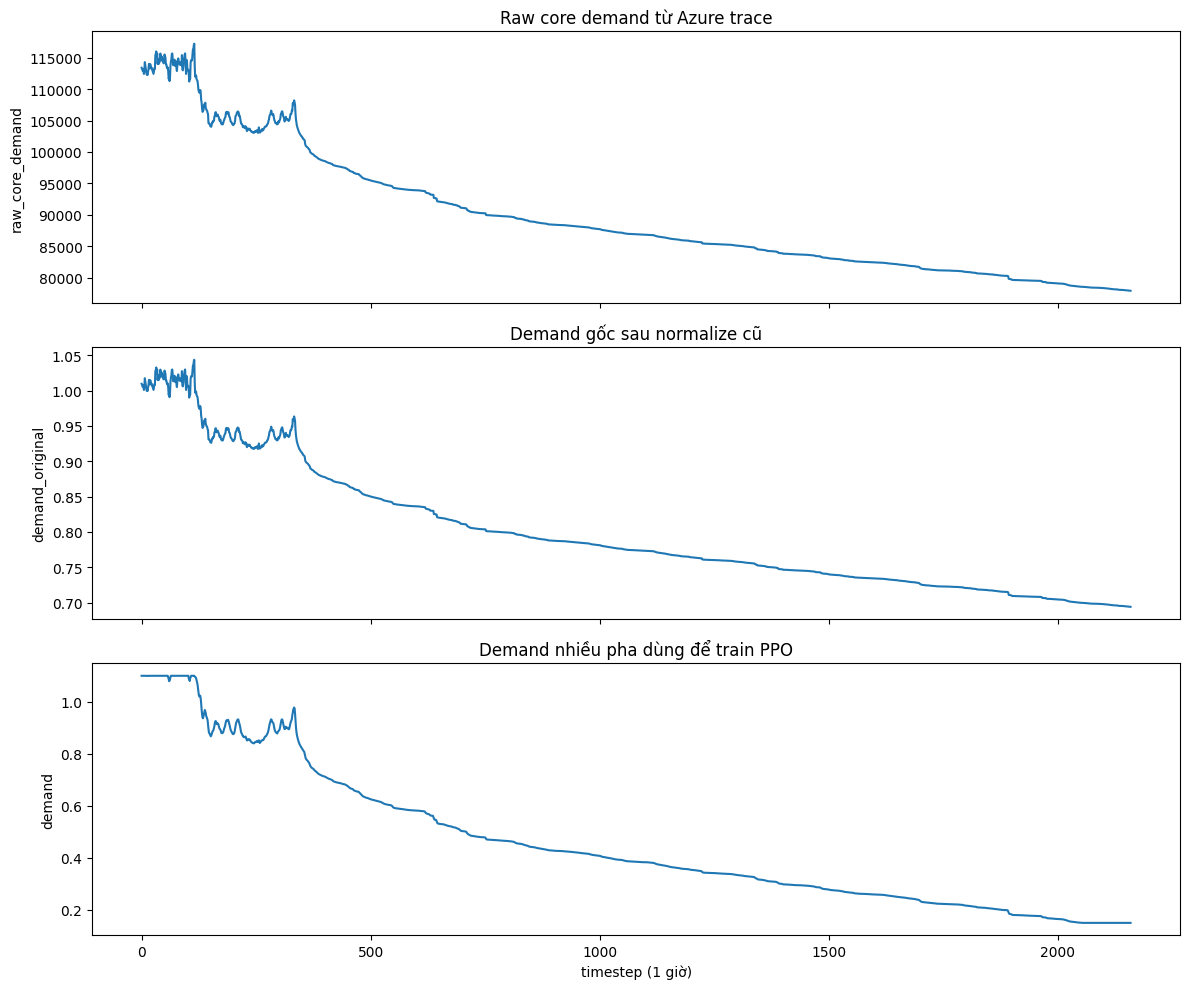

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(workload_df["timestep"], workload_df["raw_core_demand"])
axes[0].set_title("Raw core demand từ Azure trace")
axes[0].set_ylabel("raw_core_demand")

axes[1].plot(workload_df["timestep"], workload_df["demand_original"])
axes[1].set_title("Demand gốc sau normalize cũ")
axes[1].set_ylabel("demand_original")

axes[2].plot(workload_df["timestep"], workload_df["demand"])
axes[2].set_title("Demand nhiều pha dùng để train PPO")
axes[2].set_xlabel("timestep (1 giờ)")
axes[2].set_ylabel("demand")

plt.tight_layout()
plt.show()

## Bước 10.1 - Kiểm tra workload multiphase có đủ low / medium / high

Đây là kiểm tra quan trọng trước khi qua Notebook 2.

Nếu `low_count = 0`, PPO sẽ khó học Sleep/Off/DVFS_DOWN vì không có pha tải thấp.

In [16]:
phase_summary = workload_df.groupby("phase")["demand"].agg(["count", "min", "mean", "max"])
display(phase_summary)

low_count = int(phase_summary.loc["low", "count"]) if "low" in phase_summary.index else 0
medium_count = int(phase_summary.loc["medium", "count"]) if "medium" in phase_summary.index else 0
high_count = int(phase_summary.loc["high", "count"]) if "high" in phase_summary.index else 0

print("low_count =", low_count)
print("medium_count =", medium_count)
print("high_count =", high_count)

assert low_count > 0, "Chưa có low demand. Cần kiểm tra lại rescale."
assert medium_count > 0, "Chưa có medium demand. Cần kiểm tra lại rescale."
assert high_count > 0, "Chưa có high demand. Cần kiểm tra lại rescale."

print("OK: workload_multiphase có đủ low / medium / high.")

,count,min,mean,max
phase,,,,
low,1141,0.150000,0.262934,0.399790
medium,649,0.400208,0.531602,0.748998
high,370,0.750899,0.957857,1.100000


low_count = 1141
medium_count = 649
high_count = 370
OK: workload_multiphase có đủ low / medium / high.



## Bước 11 - Xem thêm số VM active theo thời gian
Cột này chưa dùng trực tiếp để train, nhưng rất hữu ích để:
- hiểu dữ liệu
- làm web demo
- vẽ thêm biểu đồ trong báo cáo


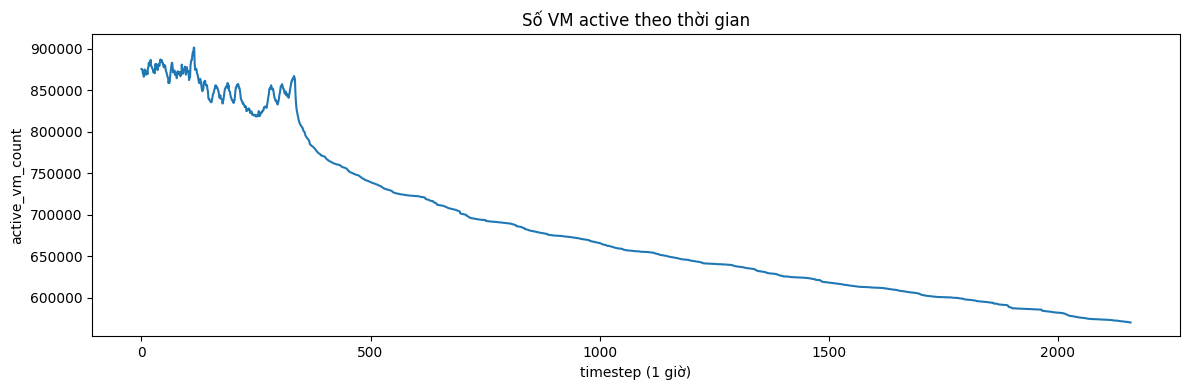

In [17]:

plt.figure(figsize=(12, 4))
plt.plot(workload_df["timestep"], workload_df["active_vm_count"])
plt.title("Số VM active theo thời gian")
plt.xlabel("timestep (1 giờ)")
plt.ylabel("active_vm_count")
plt.tight_layout()
plt.show()


## Bước 12 - Kiểm tra notebook 1 đã hoàn tất chưa

Nếu cell này chạy không lỗi và in ra đủ `True`, Notebook 1 đã tạo xong:

- workload gốc;
- workload nhiều pha;
- file alias workload_real.csv;
- vm_snapshots.csv.

In [18]:
checks = {
    "workload_real_original.csv": ORIGINAL_WORKLOAD_CSV.exists(),
    "workload_real_multiphase.csv": MULTIPHASE_WORKLOAD_CSV.exists(),
    "workload_real.csv alias": OUTPUT_CSV.exists(),
    "vm_snapshots.csv": VM_SNAPSHOT_CSV.exists(),
}

checks

{'workload_real_original.csv': True,
 'workload_real_multiphase.csv': True,
 'workload_real.csv alias': True,
 'vm_snapshots.csv': True}

## Kết luận notebook 1

Sau notebook này, ta có 4 file trong thư mục `data/`:

1. `workload_real_original.csv`

   Azure original workload (workload gốc từ Azure), dùng để báo cáo và đánh giá đối chứng.

2. `workload_real_multiphase.csv`

   Azure-derived multiphase workload (workload nhiều pha dẫn xuất từ Azure), dùng để train/evaluate PPO cho bài toán Dynamic Power Management.

3. `workload_real.csv`

   File alias giống `workload_real_multiphase.csv`, giúp Notebook 2 load dễ hơn nếu đang dùng tên cũ.

4. `vm_snapshots.csv`

   VM snapshot theo timestep, dùng để mô phỏng VM placement và migration.

Bước tiếp theo:
- qua Notebook 2;
- load `workload_real_multiphase.csv` hoặc `workload_real.csv`;
- train PPO trước 500k timestep;
- so sánh với Round Robin, Best Fit, Threshold và Fixed-Keep.